In [2]:
# Install necessary libraries
!pip install catboost lightgbm xgboost autogluon shap scikit-optimize

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.0/117.0 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 12.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. 

In [1]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, cross_validate
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from autogluon.tabular import TabularPredictor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import shap
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [2]:
# Load and preprocess the dataset
data = pd.read_csv('/content/Final_Cleaned_Voyage_Data.csv', parse_dates=['DepartureTime', 'ArrivalTime'], infer_datetime_format=True)

# Convert datetimes and calculate duration
data['DepartureTime'] = pd.to_datetime(data['DepartureTime'], format="%m/%d/%Y %H:%M")
data['ArrivalTime'] = pd.to_datetime(data['ArrivalTime'], format="%m/%d/%Y %H:%M")
data['TravelTime_seconds'] = (data['ArrivalTime'] - data['DepartureTime']).dt.total_seconds()

# Extract departure hour
data['DepartureHour'] = data['DepartureTime'].dt.hour

# Define features and target variable
numeric_features = ['LATd', 'LONd', 'LATa', 'LONa', 'Voyage_Distance_Km', 'draft_km', 'Average_Speed_Kmph',
                    'Std_SpeedKMpH', 'Avg_Course', 'breadthKM', 'DepartureHour']
categorical_features = ['vessel_type']

# Preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Handle missing values
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Handle missing values
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))  # Sparse=False for better compatibility
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

<ipython-input-2-3c47667fdeba>:2: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  data = pd.read_csv('/content/Final_Cleaned_Voyage_Data.csv', parse_dates=['DepartureTime', 'ArrivalTime'], infer_datetime_format=True)


In [3]:
# Define features and target variable
X = data[numeric_features + categorical_features]
y = data['TravelTime_seconds']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocess the data
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [4]:
# Hyperparameter Tuning for LightGBM
lgb_param_grid = {
    'num_leaves': Integer(32, 64),  # Integer range for num_leaves
    'max_depth': Integer(5, 10),    # Integer range for max_depth
    'learning_rate': Real(0.01, 0.1, prior='log-uniform'),  # Log-uniform range for learning_rate
    'n_estimators': Integer(100, 200)  # Integer range for n_estimators
}

lgb_model = LGBMRegressor(random_state=42)
lgb_bayes_search = BayesSearchCV(lgb_model, lgb_param_grid, n_iter=10, cv=5, scoring='neg_mean_squared_error', random_state=42, n_jobs=-1)
lgb_bayes_search.fit(X_train, y_train)
best_lgb_model = lgb_bayes_search.best_estimator_
lgb_y_pred = best_lgb_model.predict(X_test)

print("Best Hyperparameters for LightGBM:")
print(lgb_bayes_search.best_params_)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003251 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2565
[LightGBM] [Info] Number of data points in the train set: 15015, number of used features: 16
[LightGBM] [Info] Start training from score 313731.456210
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

In [5]:
# Train AutoGluon as a base learner
train_data_autogluon = pd.concat([pd.DataFrame(X_train, columns=numeric_features + list(preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features))),
                                  y_train.reset_index(drop=True)], axis=1)
ag_model = TabularPredictor(label='TravelTime_seconds').fit(train_data_autogluon, time_limit=600, presets='best_quality')
ag_y_pred = ag_model.predict(pd.DataFrame(X_test, columns=train_data_autogluon.columns[:-1]))

No path specified. Models will be saved in: "AutogluonModels/ag-20250114_063124"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.10.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Thu Jun 27 21:05:47 UTC 2024
CPU Count:          2
Memory Avail:       10.09 GB / 12.67 GB (79.6%)
Disk Space Avail:   74.19 GB / 107.72 GB (68.9%)
Presets specified: ['best_quality']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon will be f

(_ray_fit pid=3413) [1000]	valid_set's rmse: 48759
(_ray_fit pid=3413) [3000]	valid_set's rmse: 45183.3 [repeated 4x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
(_ray_fit pid=3413) [5000]	valid_set's rmse: 44544.8 [repeated 4x across cluster]


(_ray_fit pid=3413) 	Ran out of time, early stopping on iteration 5669. Best iteration is:
(_ray_fit pid=3413) 	[5531]	valid_set's rmse: 44475.6
(_ray_fit pid=3412) /usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
(_ray_fit pid=3412) Dask dataframe query planning is disabled because dask-expr is not installed.
(_ray_fit pid=3412) You can install it with `pip install dask[dataframe]` or `conda install dask`.
(_ray_fit pid=3412) This will raise in a future version.
(_ray_fit pid=3412)   warnings.warn(msg, FutureWarning)
(_ray_fit pid=3589) /usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
(_ray_fit pid=3589) Dask dataframe query planning is disabled because dask-expr is not installed.
(_ray_fit pid=3589) 
(_ray_fit pid=3589) You can install it with `pip install dask[dataframe]` or `conda install dask`.
(_ray_fit pid=3589) This will raise in a future version.
(_ray_fit pid=3589) 
(_ray_fit pid=3589)   warnings.warn

(_ray_fit pid=3589) [1000]	valid_set's rmse: 34653.2 [repeated 2x across cluster]
(_ray_fit pid=3588) [3000]	valid_set's rmse: 39547.2 [repeated 5x across cluster]
(_ray_fit pid=3589) [5000]	valid_set's rmse: 29950.6 [repeated 3x across cluster]


(_ray_fit pid=3589) 	Ran out of time, early stopping on iteration 5557. Best iteration is:
(_ray_fit pid=3589) 	[5517]	valid_set's rmse: 29837.5
(_ray_fit pid=3588) /usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
(_ray_fit pid=3588) Dask dataframe query planning is disabled because dask-expr is not installed.
(_ray_fit pid=3588) You can install it with `pip install dask[dataframe]` or `conda install dask`.
(_ray_fit pid=3588) This will raise in a future version.
(_ray_fit pid=3588)   warnings.warn(msg, FutureWarning)
(_ray_fit pid=3790) /usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
(_ray_fit pid=3790) Dask dataframe query planning is disabled because dask-expr is not installed.
(_ray_fit pid=3790) 
(_ray_fit pid=3790) You can install it with `pip install dask[dataframe]` or `conda install dask`.
(_ray_fit pid=3790) This will raise in a future version.
(_ray_fit pid=3790) 
(_ray_fit pid=3790)   warnings.warn

...

(_ray_fit pid=4265) 
(_ray_fit pid=4265) 
(_ray_fit pid=4265) /usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning:  [repeated 2x across cluster]
(_ray_fit pid=4265) Dask dataframe query planning is disabled because dask-expr is not installed. [repeated 2x across cluster]
(_ray_fit pid=4265) You can install it with `pip install dask[dataframe]` or `conda install dask`. [repeated 2x across cluster]
(_ray_fit pid=4265) This will raise in a future version. [repeated 2x across cluster]
(_ray_fit pid=4265)   warnings.warn(msg, FutureWarning) [repeated 2x across cluster]
(_ray_fit pid=4160) 	Ran out of time, early stopping on iteration 584. Best iteration is:
(_ray_fit pid=4160) 	[584]	valid_set's rmse: 46441.4
(_ray_fit pid=4264) 
(_ray_fit pid=4264) 


(_ray_fit pid=4265) [1000]	valid_set's rmse: 40478.2 [repeated 3x across cluster]


(_ray_fit pid=4265) 	Ran out of time, early stopping on iteration 1152. Best iteration is:
(_ray_fit pid=4265) 	[1150]	valid_set's rmse: 40199.1
(_ray_fit pid=4361) 
(_ray_fit pid=4361) 
(_ray_fit pid=4361) /usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning:  [repeated 2x across cluster]
(_ray_fit pid=4361) Dask dataframe query planning is disabled because dask-expr is not installed. [repeated 2x across cluster]
(_ray_fit pid=4361) You can install it with `pip install dask[dataframe]` or `conda install dask`. [repeated 2x across cluster]
(_ray_fit pid=4361) This will raise in a future version. [repeated 2x across cluster]
(_ray_fit pid=4361)   warnings.warn(msg, FutureWarning) [repeated 2x across cluster]
(_ray_fit pid=4264) 	Ran out of time, early stopping on iteration 1169. Best iteration is:
(_ray_fit pid=4264) 	[1163]	valid_set's rmse: 42421.9
(_ray_fit pid=4369) 
(_ray_fit pid=4369) 


(_ray_fit pid=4361) [1000]	valid_set's rmse: 44282.1 [repeated 2x across cluster]


(_ray_fit pid=4361) 	Ran out of time, early stopping on iteration 1081. Best iteration is:
(_ray_fit pid=4361) 	[1066]	valid_set's rmse: 44109.3
(_ray_fit pid=4479) 
(_ray_fit pid=4479) 
(_ray_fit pid=4479) /usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning:  [repeated 2x across cluster]
(_ray_fit pid=4479) Dask dataframe query planning is disabled because dask-expr is not installed. [repeated 2x across cluster]
(_ray_fit pid=4479) You can install it with `pip install dask[dataframe]` or `conda install dask`. [repeated 2x across cluster]
(_ray_fit pid=4479) This will raise in a future version. [repeated 2x across cluster]
(_ray_fit pid=4479)   warnings.warn(msg, FutureWarning) [repeated 2x across cluster]
(_ray_fit pid=4369) 	Ran out of time, early stopping on iteration 1051. Best iteration is:
(_ray_fit pid=4369) 	[1038]	valid_set's rmse: 35655.8
(_ray_fit pid=4480) 
(_ray_fit pid=4480) 
(_ray_fit pid=4479) 	Ran out of time, early stopping on iteratio

In [6]:
# Create meta-features from base model predictions
meta_features = pd.DataFrame({'LightGBM': lgb_y_pred, 'AutoGluon': ag_y_pred})

# Hyperparameter Tuning for XGBoost Meta-Learner
xgb_param_grid = {
    'learning_rate': Real(0.01, 0.1, prior='log-uniform'),  # Log-uniform range for learning_rate
    'n_estimators': Integer(100, 200),  # Integer range for n_estimators
    'max_depth': Integer(3, 5),  # Integer range for max_depth
    'subsample': Real(0.8, 1.0)  # Continuous range for subsample
}

xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42)
xgb_bayes_search = BayesSearchCV(xgb_model, xgb_param_grid, n_iter=10, cv=5, scoring='neg_mean_squared_error', random_state=42, n_jobs=-1)
xgb_bayes_search.fit(meta_features, y_test)
best_xgb_model = xgb_bayes_search.best_estimator_

print("Best Hyperparameters for XGBoost Meta-Learner:")
print(xgb_bayes_search.best_params_)

Best Hyperparameters for XGBoost Meta-Learner:
OrderedDict([('learning_rate', 0.0649226126117357), ('max_depth', 3), ('n_estimators', 160), ('subsample', 0.9605529562312621)])


In [7]:
# Train the best XGBoost model on meta-features
best_xgb_model.fit(meta_features, y_test)

# Evaluate stacking ensemble performance
final_predictions = best_xgb_model.predict(meta_features)
ensemble_mae = mean_absolute_error(y_test, final_predictions)
ensemble_mse = mean_squared_error(y_test, final_predictions)
ensemble_r2 = r2_score(y_test, final_predictions)

print("Stacking Ensemble (XGBoost Meta-Learner):")
print("Mean Absolute Error:", ensemble_mae)
print("Mean Squared Error:", ensemble_mse)
print("R-squared:", ensemble_r2)

Stacking Ensemble (XGBoost Meta-Learner):
Mean Absolute Error: 4386.622606719499
Mean Squared Error: 243180185.0056102
R-squared: 0.9982043025442369


In [8]:
# Cross-validation for XGBoost Meta-Learner
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'neg_mean_squared_error': 'neg_mean_squared_error',
           'neg_mean_absolute_error': 'neg_mean_absolute_error',
           'r2': 'r2'}
cv_results_xgb = cross_validate(best_xgb_model, meta_features, y_test, cv=kf, scoring=scoring)
print("XGBoost Meta-learner cross-validation results:")
print("Mean MAE:", -cv_results_xgb['test_neg_mean_absolute_error'].mean())
print("Mean MSE:", -cv_results_xgb['test_neg_mean_squared_error'].mean())
print("Mean R2:", cv_results_xgb['test_r2'].mean())

XGBoost Meta-learner cross-validation results:
Mean MAE: 5209.302595358966
Mean MSE: 399525785.02230346
Mean R2: 0.9970210228741262


In [9]:
# Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_indices = y_true != 0
    y_true_non_zero = y_true[non_zero_indices]
    y_pred_non_zero = y_pred[non_zero_indices]
    return np.mean(np.abs((y_true_non_zero - y_pred_non_zero) / y_true_non_zero)) * 100

# Compute MAPE for the Stacking Model
stacking_mape = mean_absolute_percentage_error(y_test, final_predictions)
print(f"Stacking Ensemble (XGBoost Meta-Learner) MAPE: {stacking_mape:.2f}%")

# Compute MAPE for individual models
lgb_mape = mean_absolute_percentage_error(y_test, lgb_y_pred)
ag_mape = mean_absolute_percentage_error(y_test, ag_y_pred)

print(f"LightGBM Regressor MAPE: {lgb_mape:.2f}%")
print(f"AutoGluon-Tabular MAPE: {ag_mape:.2f}%")

Stacking Ensemble (XGBoost Meta-Learner) MAPE: 0.87%
LightGBM Regressor MAPE: 1.33%
AutoGluon-Tabular MAPE: 0.64%


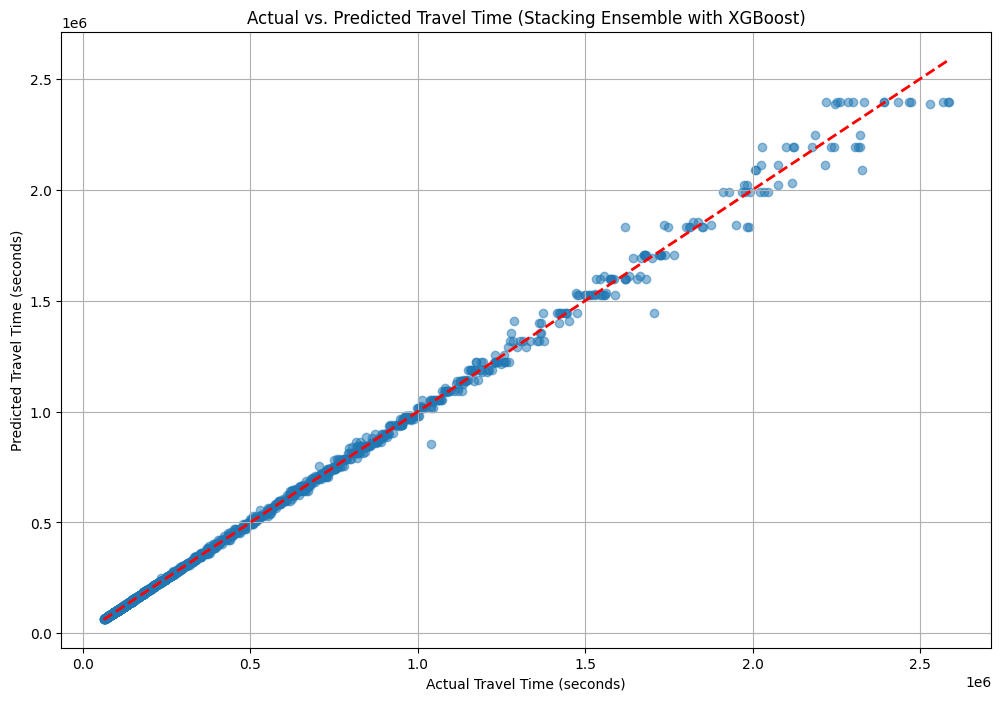

In [10]:
# Plot Actual vs. Predicted
plt.figure(figsize=(12, 8))
plt.scatter(y_test, final_predictions, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', lw=2)
plt.title('Actual vs. Predicted Travel Time (Stacking Ensemble with XGBoost)')
plt.xlabel('Actual Travel Time (seconds)')
plt.ylabel('Predicted Travel Time (seconds)')
plt.grid(True)
plt.show()

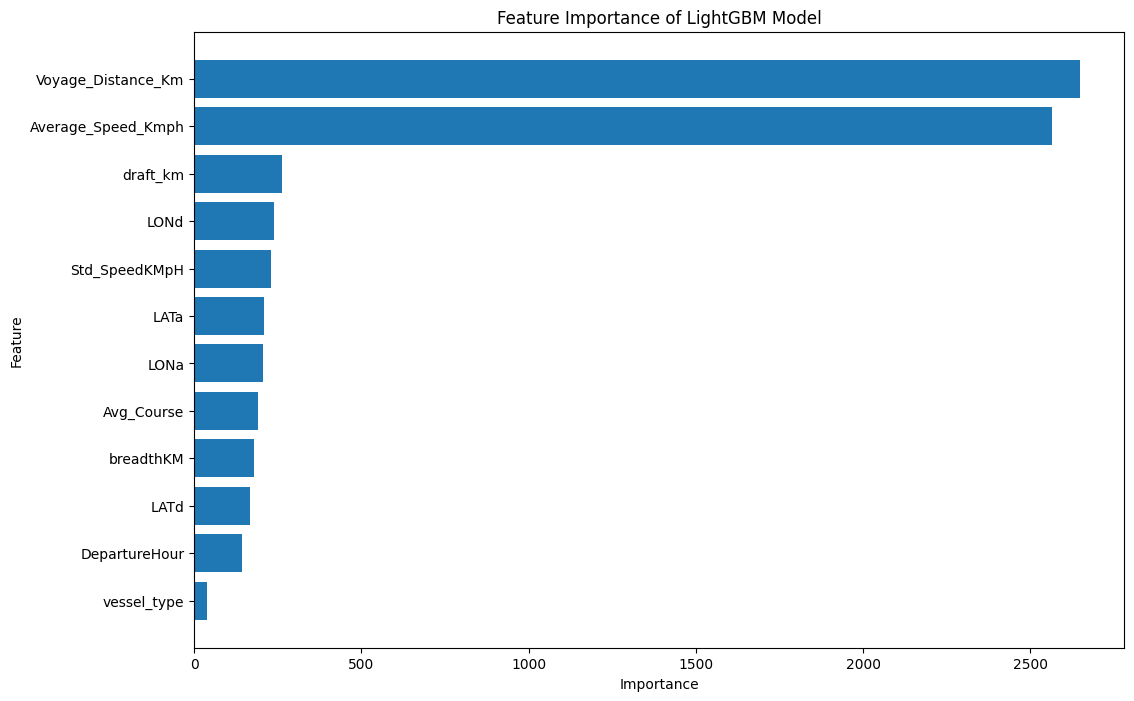

In [16]:
# Function to plot feature importance for LightGBM model
def plot_lgb_feature_importance(model, feature_names):
    importances = model.feature_importances_
    importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    importance_df = importance_df.sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(12, 8))
    plt.barh(importance_df['Feature'], importance_df['Importance'])
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.title('Feature Importance of LightGBM Model')
    plt.gca().invert_yaxis()
    plt.show()

# Get the correct feature names after preprocessing
feature_names = numeric_features + list(preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features))

# Aggregate importance for 'vessel_type' (categorical feature)
vessel_type_importance = 0
vessel_type_indices = [i for i, name in enumerate(feature_names) if name.startswith('vessel_type_')]

# Sum the importance of all one-hot encoded columns for 'vessel_type'
for idx in vessel_type_indices:
    vessel_type_importance += best_lgb_model.feature_importances_[idx]

# Remove individual one-hot encoded columns from feature_names and feature_importances
feature_names_aggregated = [name for name in feature_names if not name.startswith('vessel_type_')]
feature_importances_aggregated = [importance for i, importance in enumerate(best_lgb_model.feature_importances_) if i not in vessel_type_indices]

# Add aggregated 'vessel_type' importance
feature_names_aggregated.append('vessel_type')
feature_importances_aggregated.append(vessel_type_importance)

# Create a new LightGBM model object with aggregated feature importances
class AggregatedLightGBM:
    def __init__(self, feature_importances, feature_names):
        self.feature_importances_ = feature_importances
        self.feature_name_ = feature_names

# Create an instance of the aggregated model
aggregated_lgb_model = AggregatedLightGBM(feature_importances_aggregated, feature_names_aggregated)

# Plot feature importance
plot_lgb_feature_importance(aggregated_lgb_model, feature_names_aggregated)

Computing feature importance via permutation shuffling for 16 features using 100 rows with 5 shuffle sets...
	176.3s	= Expected runtime (35.26s per shuffle set)
	11.11s	= Actual runtime (Completed 5 of 5 shuffle sets)


Feature Importances from AutoGluon:
                       importance        stddev   p_value  n       p99_high  \
Average_Speed_Kmph  357302.188332  50233.203849  0.000046  5  460733.049354   
Voyage_Distance_Km  137660.087878  32673.772877  0.000354  5  204935.837830   
LONd                  1305.215449    364.672089  0.000661  5    2056.080321   
LATd                  1045.173531    625.227674  0.010078  5    2332.525954   
Avg_Course             672.941936    421.798650  0.011715  5    1541.431186   
Std_SpeedKMpH          241.660768    280.280533  0.063055  5     818.762259   
LATa                    99.745914    115.197518  0.062465  5     336.939195   
DepartureHour           84.593432    198.609380  0.197412  5     493.532890   
vessel_type_70          34.322114     28.971873  0.028521  5      93.975601   
draft_km                14.479404     88.334334  0.366268  5     196.361018   
vessel_type_80           0.336963      1.497052  0.320601  5       3.419413   
vessel_type_60  

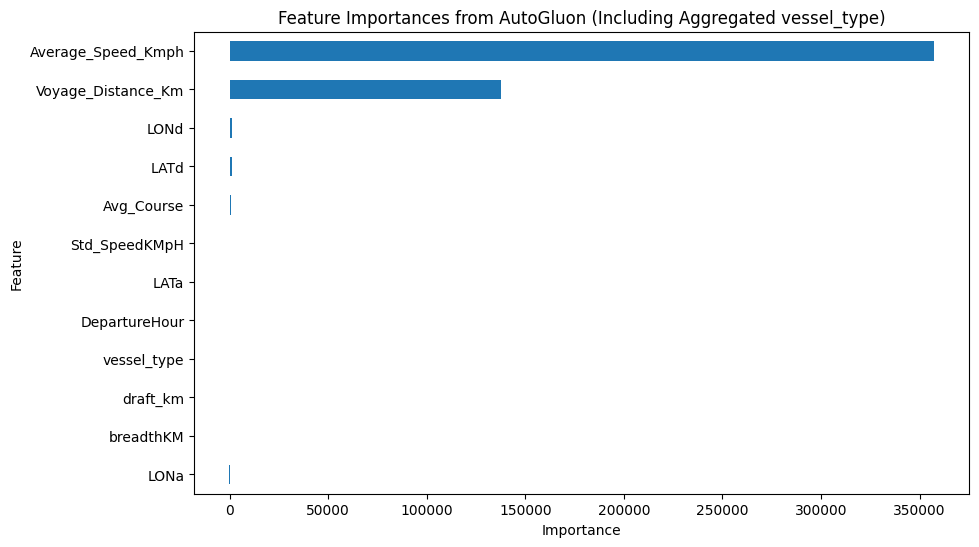

In [24]:
# Step 1: Define test_data_with_labels
# Convert X_test (NumPy array) back to a DataFrame with feature names
feature_names = numeric_features + list(preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features))
X_test_df = pd.DataFrame(X_test, columns=feature_names)

# Combine features and target for the test dataset
test_data_with_labels = pd.concat([X_test_df.reset_index(drop=True), y_test.reset_index(drop=True)], axis=1)

# Subsample the test data for faster computation
test_data_with_labels = test_data_with_labels.sample(n=100, random_state=42)

# Step 2: Calculate Feature Importance
# Use the `feature_importance` method with the correct parameters
feature_importance = ag_model.feature_importance(test_data_with_labels, feature_stage='transformed')
print("Feature Importances from AutoGluon:")
print(feature_importance)

# Step 3: Handle feature_importance object correctly
# AutoGluon's feature_importance returns a DataFrame
# Extract the importance values (assuming the column is named 'importance')
if isinstance(feature_importance, pd.DataFrame):
    feature_importance = feature_importance['importance']  # Extract the importance column

# Aggregate vessel_type importance
if any(col.startswith('vessel_type_') for col in feature_importance.index):
    vessel_type_importance = feature_importance[[col for col in feature_importance.index if col.startswith('vessel_type_')]].sum()
    feature_importance = feature_importance.drop([col for col in feature_importance.index if col.startswith('vessel_type_')])  # Remove individual one-hot columns
    feature_importance['vessel_type'] = vessel_type_importance  # Add aggregated vessel_type importance

# Sort feature importance for better visualization
feature_importance = feature_importance.sort_values(ascending=True)

# Step 4: Visualize Feature Importances
plt.figure(figsize=(10, 6))
feature_importance.plot(kind='barh')
plt.title('Feature Importances from AutoGluon (Including Aggregated vessel_type)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()